In [1]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
# import rpy2.rinterface_lib.callbacks
# from rpy2.robjects import pandas2ri

import os
import sys
import logging
import warnings

# sc.settings.verbosity = 0
# rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
# pandas2ri.activate()
# warnings.filterwarnings("ignore")
# %load_ext rpy2.ipython

In [127]:
# load file path from ocean
adata_infile = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/All_Cell_Types.h5ad'
adata_infile_fiber = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/Myofiber_scsn_RNA.h5ad'
adata_male = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_male.h5ad'
adata_female = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad'
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp'


In [128]:
adata_male = sc.read_h5ad(adata_male)
adata_female = sc.read_h5ad(adata_female)

# Male and Female Myofibers (size matched young and old samples)

In [129]:
#adata_male # need to drop P17 Male (high Barthel index (85), age = 88)
adata_female

AnnData object with n_obs × n_vars = 76546 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'rank_genes_groups'
    obsm: 'X_umap'

In [130]:
# adata_male_size_matched = adata_male[~adata_male.obs['orig.ident'].str.startswith('P17')]
# adata_male_size_matched
adata_female_size_matched = adata_female[adata_female.obs['age'].isin([18,25,34,89,90,99])]
adata_female_size_matched

View of AnnData object with n_obs × n_vars = 12111 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'rank_genes_groups'
    obsm: 'X_umap'

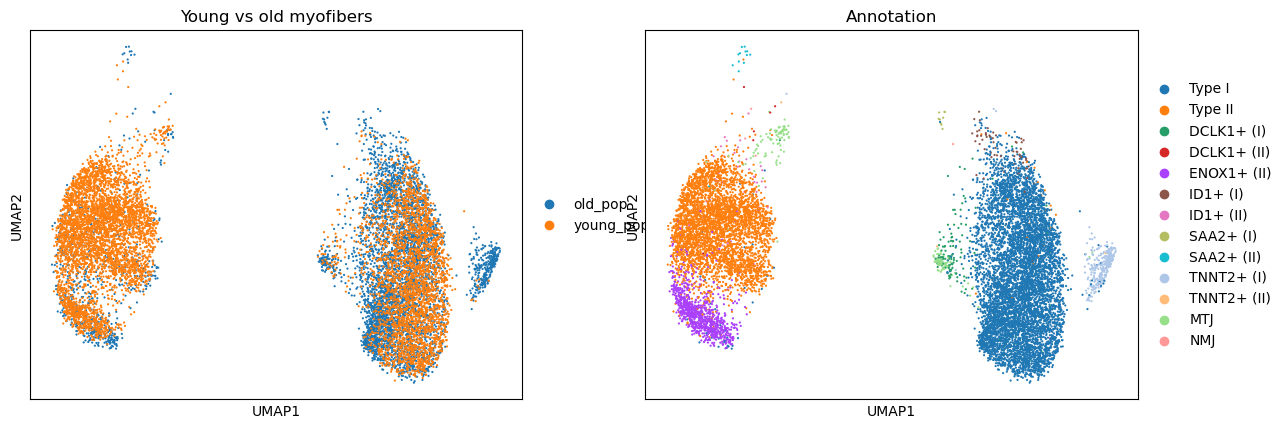

In [131]:
sc.pl.umap(adata_female_size_matched, color=['age_pop','Annotation'], title='Young vs old myofibers')

### GSEA for old as compared to young, scoring enrichment of genesets

In [132]:
adata_female_size_matched.obs['age_pop'] = pd.Categorical(adata_female_size_matched.obs['age_pop'], categories=["old_pop", "young_pop"], ordered=True)

/tmp/ipykernel_48111/329475713.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_female_size_matched.obs['age_pop'] = pd.Categorical(adata_female_size_matched.obs['age_pop'], categories=["old_pop", "young_pop"], ordered=True)


#### Subset to cell population of interest

In [156]:
bdata = adata_female_size_matched[adata_female_size_matched.obs.Annotation == "Type II"].copy()
bdata

AnnData object with n_obs × n_vars = 3860 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'rank_genes_groups'
    obsm: 'X_umap'

#### Get DEGs

In [161]:
sc.tl.rank_genes_groups(bdata,
                        groupby='age_pop',
                        use_raw=False,
                        method='wilcoxon',
                        groups=["old_pop"],
                        reference='young_pop')

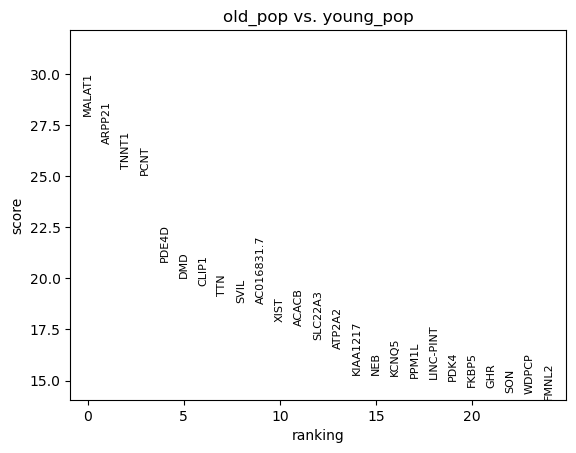

In [162]:
sc.pl.rank_genes_groups(bdata, n_genes=25, sharey=False)

In [163]:
# get deg result
result = bdata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key: result[key][group]
    for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
degs.head()

,old_pop_names,old_pop_scores,old_pop_pvals,old_pop_pvals_adj,old_pop_logfoldchanges
0,MALAT1,27.968523,3.924912e-172,2.108768e-168,0.521816
1,ARPP21,26.562567,1.838646e-155,6.839055e-152,2.794163
2,TNNT1,25.339315,1.178625e-141,3.799494e-138,5.433575
3,PCNT,25.066235,1.161599e-138,3.510569e-135,1.491598
4,PDE4D,20.794600,4.843774e-96,5.323197e-93,0.331689


#### Get GMT files for pathways of interest

In [141]:
from pathlib import Path

def gmt_to_decoupler(pth: Path) -> pd.DataFrame:
    """Parse a gmt file to a decoupler pathway dataframe."""
    from itertools import chain, repeat

    pathways = {}

    with Path(pth).open("r") as f:
        for line in f:
            name, _, *genes = line.strip().split("\t")
            pathways[name] = genes

    return pd.DataFrame.from_records(
        chain.from_iterable(zip(repeat(k), v) for k, v in pathways.items()),
        columns=["geneset", "genesymbol"],
    )

In [142]:
# load geneset of interest
dna_repair_human_gmt = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/REACTOME_DNA_REPAIR.v2024.1.Hs.gmt"

In [164]:
# subset up or down regulated genes
degs_sig = degs[degs.old_pop_pvals_adj < 0.01]
degs_up = degs_sig[degs_sig.old_pop_logfoldchanges > 0]
degs_dw = degs_sig[degs_sig.old_pop_logfoldchanges < 0]

In [165]:
degs_up.shape

(202, 5)

In [166]:
degs_dw.shape

(1175, 5)

In [173]:
enr_up = gp.enrichr(degs_up.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [174]:
enr_up.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Sarcoplasmic Reticulum Calcium Ion Transport (...,3/10,0.000116,0.047481,0,0,42.622398,386.386493,ATP2A2;RYR3;TRDN
1,GO_Biological_Process_2025,Neurotransmitter Uptake (GO:0001504),3/11,0.000158,0.047481,0,0,37.292714,326.473470,SLC22A3;SLC38A1;SLC1A3
2,GO_Biological_Process_2025,Regulation of Microtubule Polymerization (GO:0...,5/53,0.000194,0.047481,0,0,10.443105,89.284921,CLIP1;SLTM;AKAP9;KIF21A;CDK5RAP2
3,GO_Biological_Process_2025,Vascular Transport (GO:0010232),6/84,0.000208,0.047481,0,0,7.739403,65.607502,SLC22A3;SLC38A1;SLC22A5;SLC7A8;ABCC5;SLC1A3
4,GO_Biological_Process_2025,L-amino Acid Transport (GO:0015807),4/30,0.000225,0.047481,0,0,15.362859,129.017643,SLC38A1;SLC7A6;SLC7A8;SLC1A3
...,...,...,...,...,...,...,...,...,...,...
1198,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,2/455,0.946222,0.949379,0,0,0.427042,0.023606,FAF1;CCAR1
1199,GO_Biological_Process_2025,Protein-Containing Complex Assembly (GO:0065003),1/323,0.963325,0.965733,0,0,0.300918,0.011244,DMD
1200,GO_Biological_Process_2025,Proteasome-Mediated Ubiquitin-Dependent Protei...,1/340,0.969228,0.970842,0,0,0.285578,0.008926,FAF1
1201,GO_Biological_Process_2025,Protein Modification Process (GO:0036211),2/545,0.975392,0.976203,0,0,0.354604,0.008835,MAST2;SIK2


<>:3: SyntaxWarning: invalid escape sequence '\('
<>:3: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_48111/2919268616.py:3: SyntaxWarning: invalid escape sequence '\('
  enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]


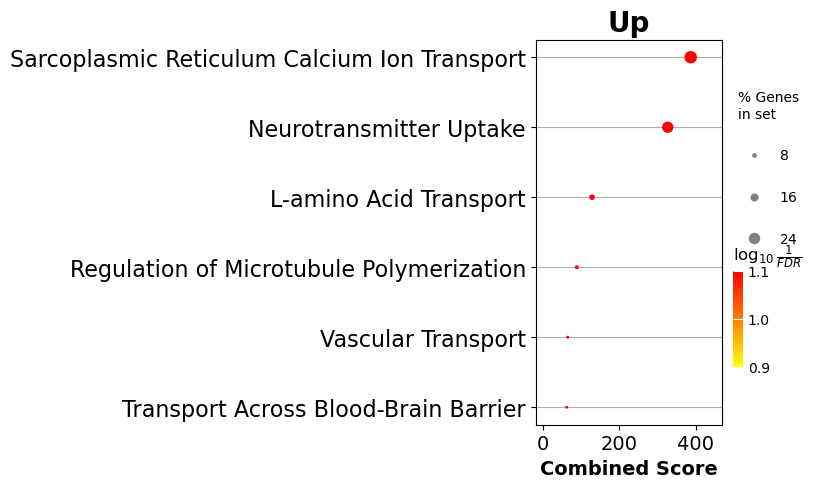

In [176]:
# dotplot
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_up.res2d, figsize=(3,5), title="Up", cmap = plt.cm.autumn_r)
plt.show()

In [178]:
enr_dw = gp.enrichr(degs_dw.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [179]:
enr_dw.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Myofibril Assembly (GO:0030239),27/51,2.549932e-20,8.271980e-17,0,0,18.424325,8.312251e+02,MYOM1;FLII;LMOD1;LMOD3;MYOM2;MYPN;LMOD2;MYOM3;...
1,GO_Biological_Process_2025,Muscle Contraction (GO:0006936),35/97,4.353673e-19,7.061657e-16,0,0,9.291242,3.928160e+02,RYR1;MYLK2;SMPX;LMOD1;LMOD3;MYOM2;CLCN1;LMOD2;...
2,GO_Biological_Process_2025,Actomyosin Structure Organization (GO:0031032),27/85,1.764734e-13,1.908265e-10,0,0,7.610071,2.234744e+02,MYOM1;FLII;LMOD1;LMOD3;MYOM2;MYPN;LMOD2;MYOM3;...
3,GO_Biological_Process_2025,Sarcomere Organization (GO:0045214),17/34,9.514150e-13,7.715975e-10,0,0,16.241796,4.495863e+02,MYOM1;MYBPC1;MYBPC2;TPM1;MYOM2;MYPN;LMOD2;MYOM...
4,GO_Biological_Process_2025,Striated Muscle Contraction (GO:0006941),18/55,1.103278e-09,7.158068e-07,0,0,7.899834,1.629339e+02,RYR1;MYLK2;DTNA;SMPX;PGAM2;TNNC2;TPM1;STAC3;AT...
...,...,...,...,...,...,...,...,...,...,...
3239,GO_Biological_Process_2025,Antimicrobial Humoral Immune Response Mediated...,1/116,9.991248e-01,9.999942e-01,0,0,0.138582,1.213377e-04,GAPDH
3240,GO_Biological_Process_2025,Defense Response to Bacterium (GO:0042742),4/221,9.991985e-01,9.999942e-01,0,0,0.292916,2.348675e-04,MAVS;TFEB;XIAP;OPTN
3241,GO_Biological_Process_2025,Antimicrobial Humoral Response (GO:0019730),1/147,9.998651e-01,9.999942e-01,0,0,0.108976,1.470520e-05,GAPDH
3242,GO_Biological_Process_2025,DNA Repair (GO:0006281),4/302,9.999825e-01,9.999942e-01,0,0,0.212369,3.717934e-06,VCP;UBE2B;ZBTB1;RAD23B


<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_48111/1711771011.py:1: SyntaxWarning: invalid escape sequence '\('
  enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]


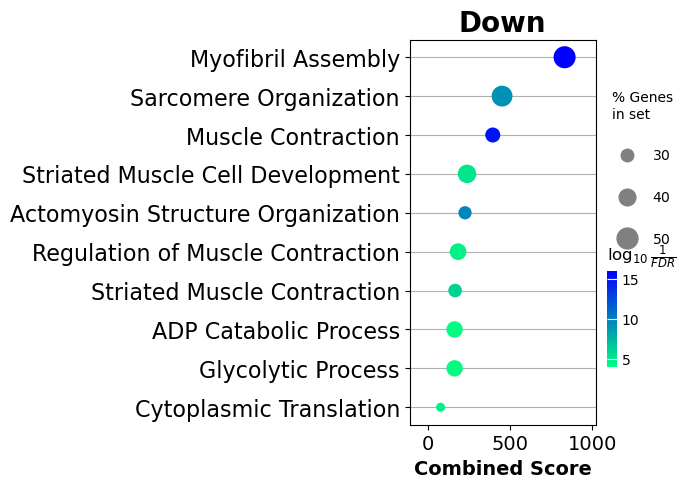

In [180]:
enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_dw.res2d,
           figsize=(3,5),
           title="Down",
           cmap = plt.cm.winter_r,
           size=5)
plt.show()